In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, RobustScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
from sklearn.ensemble import IsolationForest
import shap
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

import sys
import os

sys.path.insert(0, os.path.abspath(".."))
from scaling import scale_features

from config import load_data, FEATURES, SKEWED, FRAUD_IDS

In [26]:
df.columns

Index(['trn_id', 'trn_date', 'person_id', 'is_yellow_card', 'place_id',
       'partner_id', 'total_amount', 'discount_amount', 'bonusses_accum',
       'bonusses_used', 'trn_reg_user_code', 'person_creation_date',
       'person_first_transaction', 'trn_count_before',
       'balance_before_all_processing', 'date', 'week', 'hour', 'dow',
       'waiter_id', 'gross_amount', 'promo_used', 'is_first_trn',
       'bonus_used_flag', 'time_since_prev_trn_hours',
       'balance_after_all_processing', 'other_processings'],
      dtype='object')

In [28]:
df[(df['person_id'] == 11833164) & (df['total_amount'] == 7234.74)][['trn_date', 'person_id', 'trn_reg_user_code', 'place_id', 'total_amount']]

,trn_date,person_id,trn_reg_user_code,place_id,total_amount
1385601,2024-12-20 19:07:41+00:00,11833164,006,5ccadbb14e92d6fbcc3477a8,7234.74
1385602,2024-12-20 19:08:02+00:00,11833164,0007,5ccadbb14e92d6fbcc3477a8,7234.74
1385603,2024-12-20 19:08:36+00:00,11833164,2003,5ccadbb14e92d6fbcc3477a8,7234.74
1385604,2024-12-20 19:10:47+00:00,11833164,59,5ccadbb14e92d6fbcc3477a8,7234.74
1385605,2024-12-20 19:11:31+00:00,11833164,22,5ccadbb14e92d6fbcc3477a8,7234.74


In [ ]:
def test_model(
    df,
    features,
    skewed,
    model = 'iso',
    top = 20,
    real_fraud_ids = FRAUD_IDS
    ):
    print('Starting test_model')
    df_copy = df.copy()
    X_std = scale_features(data=df_copy, scaler_type="standard", features=features, skewed=skewed)
    print(len(real_fraud_ids))
    train_data = X_std[~X_std.index.isin(real_fraud_ids)]
    
    if model == 'ocsvm':
        ocsvm = OneClassSVM(kernel="rbf", nu=0.01, gamma="scale")
        ocsvm.fit(train_data)
        df_copy['anomaly_score_std'] = ocsvm.score_samples(X_std)
        df_copy['anomaly_label_std'] = ocsvm.predict(X_std)
        hit_rate = df_copy[df_copy['is_fraud']]["anomaly_label_std"].value_counts(normalize=True).get(-1, 0)
        top_n = df_copy['anomaly_score_std'].sort_values().head(top)
        fraud_in_top_n = top_n.index.isin(real_fraud_ids)
        n_fraud = int(df_copy['is_fraud'].sum())
        recall_at_n = fraud_in_top_n.sum() / n_fraud if n_fraud else np.nan
        precision_at_n = fraud_in_top_n.mean()
        table = pd.DataFrame({
            'score': top_n.values,
            'is_fraud': fraud_in_top_n
        }, index=top_n.index)
        print(f"One Class SVM: Anomaly Hit Rate = {hit_rate:.4f}, recall@{top} = {recall_at_n:.4f}, precision@{top} = {precision_at_n:.4f}")
        return table, df_copy, top_n, X_std
    if model == 'iso':
        iso = IsolationForest(
            n_estimators=100,
            contamination=0.001,
            random_state=42
        )
        iso.fit(train_data)
        df_copy['anomaly_score_std'] = iso.score_samples(X_std)
        df_copy['anomaly_label_std'] = iso.predict(X_std)
        hit_rate = df_copy[df_copy['is_fraud']]["anomaly_label_std"].value_counts(normalize=True).get(-1, 0)
        top_n = df_copy['anomaly_score_std'].sort_values().head(top)
        fraud_in_top_n = top_n.index.isin(real_fraud_ids)
        n_fraud = int(df_copy['is_fraud'].sum())
        recall_at_n = fraud_in_top_n.sum() / n_fraud if n_fraud else np.nan
        precision_at_n = fraud_in_top_n.mean()
        table = pd.DataFrame({
            'score': top_n.values,
            'is_fraud': fraud_in_top_n
        }, index=top_n.index)
        print(f"Isolation Forest: Anomaly Hit Rate = {hit_rate:.4f}, recall@{top} = {recall_at_n:.4f}, precision@{top} = {precision_at_n:.4f}")
        return table, df_copy, top_n, X_std

def check_top_anomaly(
    df,
    X_std,
    top_n,
    features
    ):
    fraud_ids = df[df.index.isin(top_n.index)].index
    # Sort fraud_ids by anomaly score (ascending: most anomalous first)
    fraud_ids_sorted = df.loc[fraud_ids, 'anomaly_score_std'].sort_values().index

    # Collect percentiles for each fraud person_id (for selected features)
    train = X_std[~X_std.index.isin(FRAUD_IDS)]

    features_for_table = ['anomaly_score_std'] + features
    rows = []

    for person_id in fraud_ids_sorted:
        row = {}
        for feat in features_for_table:
            if feat == 'anomaly_score_std':
                row[feat] = round(df.loc[person_id, 'anomaly_score_std'], 4)
            else:
                val = X_std.loc[person_id, feat]
                # Calculate percentile vs train
                percentile = (train[feat] < val).mean() * 100
                row[feat] = round(percentile, 2)
        rows.append(row)

    result_df = pd.DataFrame(rows, index=fraud_ids_sorted)
    result_df.index.name = "person_id"
    result_df.to_csv('res_df.csv')
    return result_df

def check_real_frauds(
    df,
    X_std,
    top_n,
    features,
    real_fraud_ids = FRAUD_IDS
):
    fraud_ids = df[df['is_fraud'] == 1].index
    fraud_ids_sorted = df.loc[fraud_ids, 'anomaly_score_std'].sort_values().index

    train = X_std[~X_std.index.isin(real_fraud_ids)]

    features_for_table = ['anomaly_score_std'] + features
    rows = []

    for person_id in fraud_ids_sorted:
        row = {}
        for feat in features_for_table:
            if feat == 'anomaly_score_std':
                row[feat] = round(df.loc[person_id, 'anomaly_score_std'], 4)
            else:
                val = X_std.loc[person_id, feat]
                percentile = (train[feat] < val).mean() * 100
                row[feat] = round(percentile, 2)
        rows.append(row)

    result_df = pd.DataFrame(rows, index=fraud_ids_sorted)
    result_df.index.name = "person_id"
    result_df.to_csv('res_df.csv')
    return result_df

df, client_data = load_data(activity_state = 2, days_visits = 2)

fraudsss = [
    11968000, 11970409, 11726701, 14827913, 12411311, 11098795, 12412748, 11812494, 12396334, 11699175,
    10896313, 16376555, 16921722, 16846666, 16794470, 16440373, 11766135, 13969910, 12234377, 12861171, 
    13076915, 13337997, 13239788, 12614443, 13119461, 13859241, 13119415, 3349318, 12830394, 12878021,
    11973649, 12199729, 11973677, 12338391, 11962124, 12396486, 12199719, 12199704, 12199723, 12199714, 12284741, 12331474, 12284496, 12342012,
    12963892, 12646735
]
client_data['is_fraud'] = client_data.index.isin(fraudsss)

features = [
    'bonus_trn_count',
    'share_top_waiter',
    'share_bonuses_used_top_waiter',
    'share_top_places',
    'num_of_trn_prcnt',
    'days_visits_prcnt',
    'gross_amount_mean_prcnt',
    'gross_amount_sum_prcnt',
    'bonuses_accum_sum_prcnt',
    'bonuses_used_sum_prcnt',
    'num_of_waiters_prcnt',
    'gross_amount_max_prcnt',
    'first_last_trn_diff_prcnt',
    'first_second_trn_diff_prcnt',
    'first_third_trn_diff_prcnt',
    'time_between_trn_median_prcnt',
    'trn_per_day_prcnt',
    'num_of_places_prcnt'
]
skewed = [
    'bonus_trn_count'
]
table, df_iso, top_20, X_std = test_model(client_data, features, skewed, model='iso', real_fraud_ids = fraudsss)
table

In [ ]:
# # Create a table for fraud person_id showing their top waiters along with the number of transactions per waiter
# fraud_person_ids = FRAUD_IDS

# fraud_waiters = {}
# max_n_waiters = 0

# for pid in fraud_person_ids:
#     waiter_counts = df[df['person_id'] == pid]['waiter_id'].value_counts()
#     # Format: "{waiter_id}   {n_trn}"
#     formatted_waiters = [f"{wid}   {ntrn}" for wid, ntrn in waiter_counts.items()]
#     fraud_waiters[pid] = formatted_waiters
#     if len(formatted_waiters) > max_n_waiters:
#         max_n_waiters = len(formatted_waiters)

# fraud_table = pd.DataFrame(index=["person_id"] + [f"{i+1} top waiter" for i in range(max_n_waiters)])

# for pid in fraud_person_ids:
#     row = [pid] + fraud_waiters[pid] + [None]*(max_n_waiters - len(fraud_waiters[pid]))
#     fraud_table[pid] = row

# fraud_table = fraud_table

# fraud_table.to_csv('fraud_table.csv')

### 1. використовую усі фічі, без жодних обмежень по активності користувача  
Isolation Forest with contamination=0.001: Anomaly Hit Rate = 0.1429, Recall = 0.0000

In [35]:
df, client_data = load_data(activity_state = 1)
X_std = scale_features(data=client_data, scaler_type="standard")

features = [
    'num_of_trn',
    'days_visits',
    'gross_amount_mean',
    'gross_amount_sum',
    'bonuses_accum_sum',
    'bonuses_used_sum',
    'num_of_waiters',
    'gross_amount_max',
    'first_last_trn_diff',
    'first_second_trn_diff',
    'first_third_trn_diff',
    'time_between_trn_median',
    'trn_per_day',
    'share_top_waiter',
    'share_bonus_trn',
    'share_bonus_after_first',
    'num_of_places',
    'share_top_places',
    'share_bonuses_used_top_waiter'
]
skewed = [
    'num_of_trn',
    'days_visits',
    'gross_amount_mean',
    'gross_amount_sum',
    'bonuses_accum_sum',
    'bonuses_used_sum',
    'num_of_waiters',
    'gross_amount_max',
    'first_last_trn_diff',
    'first_second_trn_diff',
    'first_third_trn_diff',
    'time_between_trn_median',
    'trn_per_day',
    'num_of_places'
]

X_std2 =  scale_features(
        data = client_data,
        scaler_type = "standard",
        features = features,
        skewed = skewed,
        show_charts = False,
        fit_data = None,
)
iso = IsolationForest(
    n_estimators=100,
    contamination=0.001,
    random_state=42
)

train_data = X_std2[~X_std2.index.isin(FRAUD_IDS)]
iso.fit(train_data)

client_data['anomaly_score_std'] = iso.decision_function(X_std2)
client_data['anomaly_label_std'] = iso.predict(X_std2)
hit_rate = client_data[client_data['is_fraud']]["anomaly_label_std"].value_counts(normalize=True).get(-1, 0)

top_20 = client_data['anomaly_score_std'].sort_values().head(20)
fraud_in_top_20 = top_20.index.isin(FRAUD_IDS)
n_fraud = int(client_data['is_fraud'].sum())
# recall@20 = (frauds in top 20) / total_frauds (same definition as models.py)
recall_at_20 = fraud_in_top_20.sum() / n_fraud if n_fraud else np.nan
# precision@20 = (frauds in top 20) / 20 (what the notebook previously called "Recall")
precision_at_20 = fraud_in_top_20.mean()
table = pd.DataFrame({
    'score': top_20.values,
    'is_fraud': fraud_in_top_20
}, index=top_20.index)
print(f"Isolation Forest with contamination=0.001: Anomaly Hit Rate = {hit_rate:.4f}, recall@20 = {recall_at_20:.4f}, precision@20 = {precision_at_20:.4f}")
table

Isolation Forest with contamination=0.001: Anomaly Hit Rate = 0.1429, recall@20 = 0.0000, precision@20 = 0.0000


,score,is_fraud
person_id,,
16052012,-0.056293,False
6598101,-0.055645,False
11721056,-0.043871,False
12508879,-0.042075,False
11684714,-0.042069,False
11730290,-0.040440,False
11750504,-0.036019,False
11663876,-0.033753,False
11129711,-0.032118,False


### 2. використовую усі фічі, але додаю activity_state=2 (клієнт замовляв 3+ рази), а також дні відвідувань 3+
Isolation Forest with contamination=0.001: Anomaly Hit Rate = 0.2500, Recall = 0.0000

In [36]:
df, client_data = load_data(activity_state = 2)
client_data = client_data[client_data['days_visits'] > 2]
X_std = scale_features(data=client_data, scaler_type="standard")

features = [
    'num_of_trn',
    'days_visits',
    'gross_amount_mean',
    'gross_amount_sum',
    'bonuses_accum_sum',
    'bonuses_used_sum',
    'num_of_waiters',
    'gross_amount_max',
    'first_last_trn_diff',
    'first_second_trn_diff',
    'first_third_trn_diff',
    'time_between_trn_median',
    'trn_per_day',
    'share_top_waiter',
    'share_bonus_trn',
    'share_bonus_after_first',
    'num_of_places',
    'share_top_places',
    'share_bonuses_used_top_waiter'
]
skewed = [
    'num_of_trn',
    'days_visits',
    'gross_amount_mean',
    'gross_amount_sum',
    'bonuses_accum_sum',
    'bonuses_used_sum',
    'num_of_waiters',
    'gross_amount_max',
    'first_last_trn_diff',
    'first_second_trn_diff',
    'first_third_trn_diff',
    'time_between_trn_median',
    'trn_per_day',
    'num_of_places'
]

X_std2 =  scale_features(
        data = client_data,
        scaler_type = "standard",
        features = features,
        skewed = skewed,
        show_charts = False,
        fit_data = None,
)
iso = IsolationForest(
    n_estimators=100,
    contamination=0.001,
    random_state=42
)

train_data = X_std2[~X_std2.index.isin(FRAUD_IDS)]
iso.fit(train_data)

client_data['anomaly_score_std'] = iso.decision_function(X_std2)
client_data['anomaly_label_std'] = iso.predict(X_std2)
hit_rate = client_data[client_data['is_fraud']]["anomaly_label_std"].value_counts(normalize=True).get(-1, 0)

top_20 = client_data['anomaly_score_std'].sort_values().head(20)
fraud_in_top_20 = top_20.index.isin(FRAUD_IDS)
n_fraud = int(client_data['is_fraud'].sum())
# recall@20 = (frauds in top 20) / total_frauds (same definition as models.py)
recall_at_20 = fraud_in_top_20.sum() / n_fraud if n_fraud else np.nan
# precision@20 = (frauds in top 20) / 20 (what the notebook previously called "Recall")
precision_at_20 = fraud_in_top_20.mean()
table = pd.DataFrame({
    'score': top_20.values,
    'is_fraud': fraud_in_top_20
}, index=top_20.index)
print(f"Isolation Forest with contamination=0.001: Anomaly Hit Rate = {hit_rate:.4f}, recall@20 = {recall_at_20:.4f}, precision@20 = {precision_at_20:.4f}")
table

Isolation Forest with contamination=0.001: Anomaly Hit Rate = 0.2500, recall@20 = 0.0000, precision@20 = 0.0000


,score,is_fraud
person_id,,
6598101,-0.064189,False
16052012,-0.050535,False
13995241,-0.046093,False
12508879,-0.044359,False
13074462,-0.042389,False
12715006,-0.042183,False
12270045,-0.040474,False
11790326,-0.039402,False
12547600,-0.039371,False


In [13]:
fraud_ids = client_data[client_data.index.isin(top_20.index)].index

# Sort fraud_ids by anomaly score (ascending: most anomalous first)
fraud_ids_sorted = client_data.loc[fraud_ids, 'anomaly_score_std'].sort_values().index

# Collect percentiles for each fraud person_id (for selected features)
train = X_std2[~X_std2.index.isin(FRAUD_IDS)]

features_for_table = ['anomaly_score_std'] + features
rows = []

for person_id in fraud_ids_sorted:
    row = {}
    for feat in features_for_table:
        if feat == 'anomaly_score_std':
            row[feat] = round(client_data.loc[person_id, 'anomaly_score_std'], 4)
        else:
            val = X_std2.loc[person_id, feat]
            # Calculate percentile vs train
            percentile = (train[feat] < val).mean() * 100
            row[feat] = round(percentile, 2)
    rows.append(row)

result_df = pd.DataFrame(rows, index=fraud_ids_sorted)
result_df.index.name = "person_id"
result_df.to_csv('res_df.csv')
result_df

,anomaly_score_std,num_of_trn,days_visits,gross_amount_mean,gross_amount_sum,bonuses_accum_sum,bonuses_used_sum,num_of_waiters,gross_amount_max,first_last_trn_diff,first_second_trn_diff,first_third_trn_diff,time_between_trn_median,trn_per_day,share_top_waiter,share_bonus_trn,share_bonus_after_first,num_of_places,share_top_places,share_bonuses_used_top_waiter
person_id,,,,,,,,,,,,,,,,,,,,
6598101,-0.0642,99.97,98.98,53.93,99.99,100.00,100.00,97.19,99.85,18.86,54.34,33.65,0.23,99.97,30.93,99.82,97.42,0.00,85.39,61.08
16052012,-0.0505,99.90,93.45,54.30,99.97,99.97,99.96,0.00,97.95,13.37,13.39,5.98,2.81,100.00,99.26,50.01,43.27,0.00,85.39,91.86
13995241,-0.0461,10.00,0.00,1.13,0.65,0.16,21.38,0.00,1.17,1.18,29.29,20.23,24.64,47.68,99.26,40.51,48.51,0.00,85.39,91.86
12508879,-0.0444,100.00,99.95,5.82,99.99,99.99,99.99,92.98,36.45,66.92,11.37,17.91,4.10,99.63,20.32,99.82,97.44,14.61,85.34,58.82
13074462,-0.0424,99.56,99.80,0.11,70.57,0.43,15.73,0.74,0.04,50.82,47.00,29.18,29.57,0.00,99.25,14.87,14.96,0.00,85.39,91.86
12715006,-0.0422,10.00,0.00,0.07,0.04,0.13,0.00,0.00,0.02,1.73,11.25,18.60,28.40,47.68,99.26,0.00,0.00,0.00,85.39,41.94
12270045,-0.0405,21.16,0.00,0.26,0.37,1.23,16.55,0.00,0.18,12.77,11.73,4.37,58.44,70.82,99.26,91.00,93.93,0.00,85.39,91.86
11790326,-0.0394,21.16,25.68,0.02,0.03,0.57,16.96,0.00,0.19,3.86,41.17,26.23,28.46,40.04,99.26,31.57,35.61,0.00,85.39,91.86
12547600,-0.0394,96.16,97.70,0.05,21.02,0.16,15.46,0.00,0.15,49.27,38.94,28.86,40.22,26.53,99.26,14.93,15.03,0.00,85.39,91.86


з таблиці зверху видно, що в основному картки отримують нижчий скор через аномально малі/низькі суми чеків, накобичених бофонів і тд. незважаючи на заскейлені дані, ці фічі беруться пріоритетніше

### 3. відкидаю певні фічі, а саме більшість абсолютних метрик  
- num_of_trn
- days_visits
- gross_amount_sum
- bonuses_accum_sum
- bonuses_used_sum
- num_of_waiters
- gross_amount_max
- num_of_places  

за рахунок цих метрик багато карток афектяться як аномалії, хоча насправді це можуть бути старі клієнти з великою базою транзакцій. для них фічі по типу великих сум чеків, к-ті транзакцій і тд будуть пріоритетнішими за рейтові метрики, хоча в даному контексті вони цінності не несуть.  

Isolation Forest: Anomaly Hit Rate = 0.2143, recall@20 = 0.0357, precision@20 = 0.0500

In [65]:
df, client_data = load_data(activity_state = 2, days_visits = 2)
X_std = scale_features(data=client_data, scaler_type="standard")

features = [
    # 'num_of_trn',
    # 'days_visits',
    'gross_amount_mean',
    # 'gross_amount_sum',
    # 'bonuses_accum_sum',
    # 'bonuses_used_sum',
    # 'num_of_waiters',
    # 'gross_amount_max',
    'first_last_trn_diff',
    'first_second_trn_diff',
    'first_third_trn_diff',
    'time_between_trn_median',
    'trn_per_day',
    'share_top_waiter',
    'share_bonus_trn',
    'share_bonus_after_first',
    # 'num_of_places',
    'share_top_places',
    'share_bonuses_used_top_waiter'
]
skewed = [
    # 'num_of_trn',
    # 'days_visits',
    'gross_amount_mean',
    # 'gross_amount_sum',
    # 'bonuses_accum_sum',
    # 'bonuses_used_sum',
    # 'num_of_waiters',
    # 'gross_amount_max',
    'first_last_trn_diff',
    'first_second_trn_diff',
    'first_third_trn_diff',
    'time_between_trn_median',
    'trn_per_day',
    # 'num_of_places'
]

table, df_iso, top_20, X_std = test_model(client_data, features, skewed, model='iso')
table

Starting test_model
Isolation Forest: Anomaly Hit Rate = 0.2143, recall@20 = 0.0357, precision@20 = 0.0500


,score,is_fraud
person_id,,
12231243,-0.051868,False
11667048,-0.050155,False
16234805,-0.047609,False
15595950,-0.046416,False
12380638,-0.046385,False
11876561,-0.042187,False
11962560,-0.041730,False
13099115,-0.041467,False
16846666,-0.040801,True


In [ ]:
check_top_anomaly(df_iso, X_std, top_20, features)

In [ ]:
check_real_frauds(df_iso, X_std, top_20, features)

In [69]:
from sklearn.manifold import TSNE
import plotly.express as px
import numpy as np

top_n = 20
detected_fraud_idx = df_iso[df_iso['anomaly_label_std'] == -1].index
real_fraud_idx = df_iso[df_iso['is_fraud'] == True].index
normal_data = df_iso[~df_iso.index.isin(detected_fraud_idx) & ~df_iso.index.isin(real_fraud_idx)]

sample_size = 3000
nonfraud_idx = normal_data.sample(n=sample_size, random_state=42).index
sample_idx = nonfraud_idx.union(real_fraud_idx)
sample_idx = sample_idx.union(detected_fraud_idx)
X_std_sample = X_std.loc[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=20)
tsne_results = tsne.fit_transform(X_std_sample)

tsne_df = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'], index=X_std_sample.index)
tsne_df['is_fraud'] = client_data.loc[X_std_sample.index, 'is_fraud']
tsne_df['anomaly_score'] = df_iso.loc[X_std_sample.index, 'anomaly_score_std']

tsne_df['group'] = 'Normal'
tsne_df.loc[tsne_df['is_fraud'] == True, 'group'] = 'Real Fraud'
tsne_df.loc[(tsne_df.index.isin(detected_fraud_idx)) & (tsne_df['is_fraud'] == False), 'group'] = 'Detected Fraud'

tsne_df['group'] = pd.Categorical(
    tsne_df['group'],
    categories=['Real Fraud', 'Detected Fraud', 'Normal'],
    ordered=True
)

color_map = {
    'Real Fraud': '#d62728',
    'Detected Fraud': '#ff7f0e',
    'Normal': '#1f77b4'
}

fig = px.scatter(
    tsne_df,
    x='tsne_1',
    y='tsne_2',
    color='group',
    color_discrete_map=color_map,
    symbol='group',
    title="t-SNE Projection: Real Fraud (red), Detected Fraud (orange), Normal Data (blue)",
    labels={'group': 'Group'},
    hover_data=['anomaly_score', 'is_fraud'],
)

fig.update_traces(marker=dict(size=5, opacity=1))
fig.show()

### 4. відкидаю фічу share_bonus_trn
порівнюючи дві таблиці зверху бачимо, що аномаліями детектяться переважно картки, де висока частка share_bonus_trn. в той час як на реальних фрод транзакціях це не так однозначно. половина карток не так сильно відхиляється саме по share_bonus_trn

top20 recall 5% -> 20% 

Isolation Forest: Anomaly Hit Rate = 0.5349, recall@20 = 0.1860, precision@20 = 0.4000

In [17]:
df, client_data = load_data(activity_state = 2, days_visits = 2)

fraudsss = [
    11968000, 11970409, 11726701, 14827913, 12411311, 11098795, 12412748, 11812494, 12396334, 11699175,
    10896313, 16376555, 16921722, 16846666, 16794470, 16440373, 11766135, 13969910, 12234377, 12861171, 
    13076915, 13337997, 13239788, 12614443, 13119461, 13859241, 13119415, 3349318, 12830394, 12878021,
    11973649, 12199729, 11973677, 12338391, 11962124, 12396486, 12199719, 12199704, 12199723, 12199714, 12284741, 12331474, 12284496, 12342012,
    12963892, 12646735
]
client_data['is_fraud'] = client_data.index.isin(fraudsss)

features = [
    'bonus_trn_count',
    'share_top_waiter',
    'share_bonuses_used_top_waiter',
    'share_top_places',
    'num_of_trn_prcnt',
    'days_visits_prcnt',
    'gross_amount_mean_prcnt',
    'gross_amount_sum_prcnt',
    'bonuses_accum_sum_prcnt',
    'bonuses_used_sum_prcnt',
    'num_of_waiters_prcnt',
    'gross_amount_max_prcnt',
    'first_last_trn_diff_prcnt',
    'first_second_trn_diff_prcnt',
    'first_third_trn_diff_prcnt',
    'time_between_trn_median_prcnt',
    'trn_per_day_prcnt',
    'num_of_places_prcnt'
]
skewed = [
    'bonus_trn_count'
]
table, df_iso, top_20, X_std = test_model(client_data, features, skewed, model='iso', real_fraud_ids = fraudsss)
table

Starting test_model
46
Isolation Forest: Anomaly Hit Rate = 0.5349, recall@20 = 0.1860, precision@20 = 0.4000


,score,is_fraud
person_id,,
16052012,-0.671689,False
16118378,-0.659095,False
16794470,-0.656390,True
14857764,-0.654195,False
12296587,-0.652863,False
11112614,-0.651140,False
12396486,-0.650105,True
11974519,-0.647997,False
11589082,-0.647628,False


In [98]:
fraud_waiter_ids = client_data[client_data['is_fraud'] == 1]['top_waiter_id'].unique()

new_frauds = df_iso[
    (df_iso['top_waiter_id'].isin(fraud_waiter_ids)) 
    & (df_iso['is_fraud'] == 0)
    & (df_iso['share_top_waiter'] >= 0.9) 
    & (df_iso['num_of_trn'] >= 10)
    ].index.values.tolist()

FRAUD_IDS = [
    11968000, 11970409, 11726701, 14827913, 12411311, 11098795, 12412748, 11812494, 12396334, 11699175,
    10896313, 16376555, 16921722, 16846666, 16794470, 16440373, 11766135, 13969910, 12234377, 12861171, 
    13076915, 13337997, 13239788, 12614443, 12646735, 13119461, 13859241, 13119415, 3349318, 12830394, 12878021
    # , 11738983
]
FRAUD_IDS = FRAUD_IDS + new_frauds

In [99]:
fraud_waiters = [
    '539f5da6c76b7cd7fa3d859c_56',
    '539f5da6c76b7cd7fa3d859f_...',
    '539f5da6c76b7cd7fa3d859f_547',
    '539f5da6c76b7cd7fa3d859f_121',
    '542704afe4b07d8ca118acb2_18343',
    '539f5da6c76b7cd7fa3d859c_09',
    '5bbf439c4e928fc6872920fe_16694',
    '539f5da8c76b7cd7fa3d85dd_111',
    '539f5da8c76b7cd7fa3d85dd_7921',
    '539f5da8c76b7cd7fa3d85dd_3972',
    '539f5da8c76b7cd7fa3d85dd_9748',
    '539f5da8c76b7cd7fa3d85dd_1947',
    '54de0d442cdc51c13b68ed82_2045',
    '539f5da8c76b7cd7fa3d85d8_2045',
    '539f5da8c76b7cd7fa3d85d8_482109436',
    '65117ad169a6f4704ea03ecd_18368',
    '65117ad169a6f4704ea03ecd_2022',
    '601c0e3a4e92a83b9f84122c_1111',
    '601c0e3a4e92a83b9f84122c_7777',
    '601c0e3a4e92a83b9f84122c_122',
    '601c0e3a4e92a83b9f84122c_16467',
    '601c0e3a4e92a83b9f84122c_5252',
    '601c0e3a4e92a83b9f84122c_0597',
    '601c0e3a4e92a83b9f84122c_8874',
    '539f5da7c76b7cd7fa3d85af_6094',
    '539f5da7c76b7cd7fa3d85af_2197',
    '539f5da7c76b7cd7fa3d85af_6729',
    '601c0e3a4e92a83b9f84122c_7536',
    '602b89094e9293740b7f39a3_8885',
    '602b89094e9293740b7f39a3_66',
    '602b89094e9293740b7f39a3_1009',
    '601c0e3a4e92a83b9f84122c_15933',
]

fraud_waiter_ids
# df_iso.columns
# df_iso[(df_iso['top_waiter_id'].isin(fraud_waiter_ids)) & (df_iso['is_fraud'] == 0)][['num_of_trn', 'top_waiter_id', 'share_top_waiter', 'is_fraud', 'anomaly_score_std', 'anomaly_label_std']].sort_values(by='anomaly_score_std', ascending=True)


test_client_data = client_data.copy()
test_client_data['is_fraud'] = test_client_data.index.isin(FRAUD_IDS)
table, df_iso, top_20, X_std = test_model(test_client_data, features, skewed, model='iso')
frauds = table.index.values
table

Starting test_model
Isolation Forest: Anomaly Hit Rate = 0.3467, recall@20 = 0.0400, precision@20 = 0.1500


,score,is_fraud
person_id,,
16052012,-0.051839,False
11973649,-0.039436,False
12284741,-0.039286,False
15093281,-0.038214,False
12199729,-0.037167,False
12199719,-0.035773,False
12338391,-0.033071,False
12397604,-0.031824,False
11763106,-0.030233,False


In [103]:
df[df['person_id'] == 16052012]['waiter_id'].value_counts()

waiter_id
539f5da8c76b7cd7fa3d85e8_24    242
Name: count, dtype: Int64

In [106]:
df[df['place_id'] == '539f5da8c76b7cd7fa3d85e8']['waiter_id'].value_counts()

waiter_id
539f5da8c76b7cd7fa3d85e8_25     975
539f5da8c76b7cd7fa3d85e8_24     671
539f5da8c76b7cd7fa3d85e8_23      40
539f5da8c76b7cd7fa3d85e8_369      3
539f5da8c76b7cd7fa3d85e8_22       3
539f5da8c76b7cd7fa3d85e8_123      1
539f5da8c76b7cd7fa3d85e8_147      1
Name: count, dtype: Int64

In [105]:
df_iso[df_iso.index == 16052012][features]

,bonus_trn_count,share_top_waiter,share_bonuses_used_top_waiter,share_top_places,num_of_trn_prcnt,days_visits_prcnt,gross_amount_mean_prcnt,gross_amount_sum_prcnt,bonuses_accum_sum_prcnt,bonuses_used_sum_prcnt,num_of_waiters_prcnt,gross_amount_max_prcnt,first_last_trn_diff_prcnt,first_second_trn_diff_prcnt,first_third_trn_diff_prcnt,time_between_trn_median_prcnt,trn_per_day_prcnt,num_of_places_prcnt
person_id,,,,,,,,,,,,,,,,,,
16052012,68,1.0,1.0,1.0,0.999039,0.936902,0.542973,0.999742,0.999676,0.999626,0.003732,0.979511,0.133741,0.133976,0.059822,0.02815,0.999972,0.07309


In [100]:
check_top_anomaly(df_iso, X_std, top_20, features)

,anomaly_score_std,bonus_trn_count,share_top_waiter,share_bonuses_used_top_waiter,share_top_places,num_of_trn_prcnt,days_visits_prcnt,gross_amount_mean_prcnt,gross_amount_sum_prcnt,bonuses_accum_sum_prcnt,bonuses_used_sum_prcnt,num_of_waiters_prcnt,gross_amount_max_prcnt,first_last_trn_diff_prcnt,first_second_trn_diff_prcnt,first_third_trn_diff_prcnt,time_between_trn_median_prcnt,trn_per_day_prcnt,num_of_places_prcnt
person_id,,,,,,,,,,,,,,,,,,,
16052012,-0.0518,99.84,99.27,91.88,85.40,99.90,93.45,54.29,99.97,99.97,99.96,0.00,97.95,13.37,13.39,5.98,2.81,100.00,0.00
11973649,-0.0394,94.93,99.27,91.88,85.40,90.72,95.14,94.66,99.11,99.66,99.76,0.00,88.90,17.50,37.52,29.91,35.11,0.00,0.00
12284741,-0.0393,67.76,99.27,91.88,85.40,59.72,72.88,98.26,95.81,98.71,99.14,0.00,94.02,8.30,18.28,27.66,33.13,28.41,0.00
15093281,-0.0382,36.26,99.27,91.88,85.40,0.00,0.00,99.98,94.85,96.49,88.65,0.00,99.74,15.19,47.51,64.23,78.28,0.00,0.00
12199729,-0.0372,92.81,99.27,91.88,85.40,88.48,93.45,96.27,99.10,99.49,99.56,0.00,93.35,15.66,41.92,35.94,35.47,25.46,0.00
12199719,-0.0358,86.28,99.27,91.88,85.40,81.06,89.81,97.08,98.33,99.43,99.49,0.00,96.92,15.63,40.68,24.27,37.47,0.00,0.00
12338391,-0.0331,67.76,99.27,91.88,85.40,64.38,79.72,96.91,95.03,98.99,99.31,0.00,95.45,7.60,42.40,28.21,31.05,0.00,0.00
12397604,-0.0318,99.74,98.41,91.14,85.40,99.43,98.46,17.66,97.95,97.68,98.62,32.60,80.86,69.54,0.37,68.37,7.70,90.29,0.00
11763106,-0.0302,99.59,97.67,91.04,82.95,99.85,99.69,2.95,97.94,97.56,98.33,85.92,15.22,93.39,98.68,95.35,22.27,82.16,82.67


In [88]:
# FRAUD_IDS = [
#     11968000, 11970409, 11726701, 14827913, 12411311, 11098795, 12412748, 11812494, 12396334, 11699175,
#     10896313, 16376555, 16921722, 16846666, 16794470, 16440373, 11766135, 13969910, 12234377, 12861171, 
#     13076915, 13337997, 13239788, 12614443, 12646735, 13119461, 13859241, 13119415, 3349318, 12830394, 12878021
#     # , 11738983
# ]

fraud_waiters = [
    '539f5da6c76b7cd7fa3d859c_56',
    '539f5da6c76b7cd7fa3d859f_...',
    '539f5da6c76b7cd7fa3d859f_547',
    '539f5da6c76b7cd7fa3d859f_121',
    '542704afe4b07d8ca118acb2_18343',
    '539f5da6c76b7cd7fa3d859c_09',
    '5bbf439c4e928fc6872920fe_16694',
    '539f5da8c76b7cd7fa3d85dd_111',
    '539f5da8c76b7cd7fa3d85dd_7921',
    '539f5da8c76b7cd7fa3d85dd_3972',
    '539f5da8c76b7cd7fa3d85dd_9748',
    '539f5da8c76b7cd7fa3d85dd_1947',
    '54de0d442cdc51c13b68ed82_2045',
    '539f5da8c76b7cd7fa3d85d8_2045',
    '539f5da8c76b7cd7fa3d85d8_482109436',
    '65117ad169a6f4704ea03ecd_18368',
    '65117ad169a6f4704ea03ecd_2022',
    '601c0e3a4e92a83b9f84122c_1111',
    '601c0e3a4e92a83b9f84122c_7777',
    '601c0e3a4e92a83b9f84122c_122',
    '601c0e3a4e92a83b9f84122c_16467',
    '601c0e3a4e92a83b9f84122c_5252',
    '601c0e3a4e92a83b9f84122c_0597',
    '601c0e3a4e92a83b9f84122c_8874',
    '539f5da7c76b7cd7fa3d85af_6094',
    '539f5da7c76b7cd7fa3d85af_2197',
    '539f5da7c76b7cd7fa3d85af_6729',
    '601c0e3a4e92a83b9f84122c_7536',
    '602b89094e9293740b7f39a3_8885',
    '602b89094e9293740b7f39a3_66',
    '602b89094e9293740b7f39a3_1009',
    '601c0e3a4e92a83b9f84122c_15933',
]
fraud_waiter_ids = client_data[client_data['is_fraud'] == 1]['top_waiter_id'].unique()
fraud_waiter_ids
# df_iso.columns
# df_iso[(df_iso['top_waiter_id'].isin(fraud_waiter_ids)) & (df_iso['is_fraud'] == 0)][['num_of_trn', 'top_waiter_id', 'share_top_waiter', 'is_fraud', 'anomaly_score_std', 'anomaly_label_std']].sort_values(by='anomaly_score_std', ascending=True)
new_frauds = df_iso[(df_iso['top_waiter_id'].isin(fraud_waiter_ids)) & (df_iso['is_fraud'] == 0)].index.values
FRAUD_IDS = FRAUD_IDS + new_frauds.tolist() + frauds.tolist()

test_client_data = client_data.copy()
test_client_data['is_fraud'] = test_client_data.index.isin(FRAUD_IDS)
table, df_iso, top_20, X_std = test_model(test_client_data, features, skewed, model='iso')
frauds = table.index.values
table

Starting test_model
Isolation Forest: Anomaly Hit Rate = 0.0168, recall@20 = 0.0055, precision@20 = 0.7000


,score,is_fraud
person_id,,
16052012,-0.051045,True
16118378,-0.048753,True
11112614,-0.044686,True
12296587,-0.042969,True
13025358,-0.042099,True
11974519,-0.038934,True
12569209,-0.037622,False
16794470,-0.036807,True
11833164,-0.035970,False


In [73]:
check_top_anomaly(df_iso, X_std, top_20, features)

,anomaly_score_std,bonus_trn_count,share_top_waiter,share_bonuses_used_top_waiter,share_top_places,num_of_trn_prcnt,days_visits_prcnt,gross_amount_mean_prcnt,gross_amount_sum_prcnt,bonuses_accum_sum_prcnt,bonuses_used_sum_prcnt,num_of_waiters_prcnt,gross_amount_max_prcnt,first_last_trn_diff_prcnt,first_second_trn_diff_prcnt,first_third_trn_diff_prcnt,time_between_trn_median_prcnt,trn_per_day_prcnt,num_of_places_prcnt
person_id,,,,,,,,,,,,,,,,,,,
11974519,-0.0468,99.84,99.13,91.86,85.39,99.86,99.75,9.76,99.35,99.41,99.49,0.74,30.33,77.96,14.79,4.24,26.63,80.83,0.00
16052012,-0.0466,99.84,99.26,91.86,85.39,99.90,93.45,54.30,99.97,99.97,99.96,0.00,97.95,13.37,13.39,5.98,2.81,100.00,0.00
11112614,-0.0464,99.40,99.26,91.86,85.39,99.37,98.63,7.56,94.97,90.96,93.16,0.00,74.72,24.83,22.32,7.03,17.34,87.40,0.00
12861171,-0.0447,98.98,98.80,91.71,85.39,98.18,99.04,98.98,99.98,99.98,99.98,4.51,97.74,36.82,44.75,27.03,38.28,25.08,0.00
11763106,-0.0378,99.60,97.65,91.03,82.94,99.85,99.69,2.96,97.94,97.56,98.33,85.92,15.23,93.39,98.68,95.36,22.26,82.16,82.68
12397604,-0.0355,99.74,98.39,91.13,85.39,99.44,98.46,17.66,97.95,97.68,98.62,32.61,80.86,69.54,0.37,68.37,7.70,90.29,0.00
11590792,-0.0345,99.92,98.36,91.57,85.39,99.91,99.91,25.63,99.88,99.87,99.92,32.61,40.80,99.98,87.49,76.25,26.24,59.57,0.00
11832953,-0.0343,99.94,98.80,91.02,85.37,99.93,99.46,20.87,99.87,99.89,99.91,4.51,66.52,28.82,22.96,30.36,8.40,98.34,14.61
11551820,-0.0339,98.58,99.26,91.86,85.39,98.94,98.31,5.90,89.79,88.77,92.47,0.00,33.59,24.84,55.35,34.44,24.30,78.58,0.00


In [89]:
# df_iso.loc[[12397604], ['top_waiter_id'] + features]
df_iso[df_iso.index == 11664406][['num_of_trn']+['num_of_waiters'] + ['top_waiter_id'] + features]

,num_of_trn,num_of_waiters,top_waiter_id,bonus_trn_count,share_top_waiter,share_bonuses_used_top_waiter,share_top_places,num_of_trn_prcnt,days_visits_prcnt,gross_amount_mean_prcnt,...,bonuses_accum_sum_prcnt,bonuses_used_sum_prcnt,num_of_waiters_prcnt,gross_amount_max_prcnt,first_last_trn_diff_prcnt,first_second_trn_diff_prcnt,first_third_trn_diff_prcnt,time_between_trn_median_prcnt,trn_per_day_prcnt,num_of_places_prcnt
person_id,,,,,,,,,,,,,,,,,,,,,
11664406,137,5,60756e7d4e92b29b3d9bfd1f_10201020,72,0.788321,0.861111,1.0,0.996458,0.990542,0.01429,...,0.910261,0.938624,0.384713,0.25301,0.483018,0.456683,0.321375,0.154958,0.891951,0.07309


In [68]:
df[df['person_id'] == 12397604]['waiter_id'].value_counts()

waiter_id
5ece5c884e92c7f8793ddd44_2005     85
5ece5c884e92c7f8793ddd44_5245     19
5ece5c884e92c7f8793ddd44_9068      3
5ece5c884e92c7f8793ddd44_2045      2
5ece5c884e92c7f8793ddd44_16748     1
Name: count, dtype: Int64

In [66]:
df[df['place_id'] == '5b02cc4e2cdc91e2becc0fd5']['waiter_id'].value_counts()

waiter_id
5b02cc4e2cdc91e2becc0fd5_456           22795
5b02cc4e2cdc91e2becc0fd5_2045           6675
5b02cc4e2cdc91e2becc0fd5_1               297
5b02cc4e2cdc91e2becc0fd5_2                 7
5b02cc4e2cdc91e2becc0fd5_vLevankova        1
Name: count, dtype: Int64

In [56]:
check_top_anomaly(df_iso, X_std, top_20, features)

,anomaly_score_std,bonus_trn_count,share_top_waiter,share_bonuses_used_top_waiter,share_top_places,num_of_trn_prcnt,days_visits_prcnt,gross_amount_mean_prcnt,gross_amount_sum_prcnt,bonuses_accum_sum_prcnt,bonuses_used_sum_prcnt,num_of_waiters_prcnt,gross_amount_max_prcnt,first_last_trn_diff_prcnt,first_second_trn_diff_prcnt,first_third_trn_diff_prcnt,time_between_trn_median_prcnt,trn_per_day_prcnt,num_of_places_prcnt
person_id,,,,,,,,,,,,,,,,,,,
16052012,-0.0701,99.84,99.33,91.94,85.50,99.90,93.47,54.23,99.98,99.97,99.96,0.00,97.96,13.38,13.36,5.99,2.82,100.00,0.00
16118378,-0.0579,98.70,99.33,91.94,85.50,98.71,92.88,10.91,92.02,93.68,94.67,0.00,24.97,12.38,20.81,6.30,4.23,98.51,0.00
12397604,-0.0550,99.74,98.50,91.22,85.50,99.43,98.46,17.61,97.96,97.69,98.63,32.46,80.84,69.64,0.37,68.32,7.74,90.22,0.00
12420476,-0.0481,99.42,97.80,91.20,85.50,97.79,90.75,21.16,92.05,92.63,95.67,4.37,35.95,24.73,20.95,5.45,7.96,97.39,0.00
11112614,-0.0472,99.39,99.33,91.94,85.50,99.37,98.63,7.52,94.98,90.96,93.17,0.00,74.69,24.89,22.30,7.05,17.44,87.32,0.00
11974519,-0.0468,99.83,99.21,91.93,85.50,99.86,99.75,9.72,99.35,99.41,99.49,0.67,30.28,78.03,14.76,4.25,26.74,80.73,0.00
15136877,-0.0462,99.74,98.57,91.15,85.50,99.89,97.19,43.06,99.95,99.89,99.79,0.67,90.24,22.28,48.10,34.22,2.82,99.96,0.00
11832953,-0.0450,99.94,98.90,91.12,85.47,99.93,99.46,20.81,99.87,99.88,99.91,4.37,66.48,28.89,22.95,30.28,8.45,98.32,14.50
11766135,-0.0429,94.94,99.26,91.80,85.50,98.81,95.46,65.49,99.59,98.91,98.74,0.67,92.27,92.91,70.07,74.24,9.98,96.10,0.00


In [33]:
df[df['person_id'] == 11862767]['waiter_id'].value_counts()

waiter_id
54de0d442cdc51c13b68ed82_2045    6
54de0d442cdc51c13b68ed82_2603    1
54de0d442cdc51c13b68ed82_1311    1
Name: count, dtype: Int64

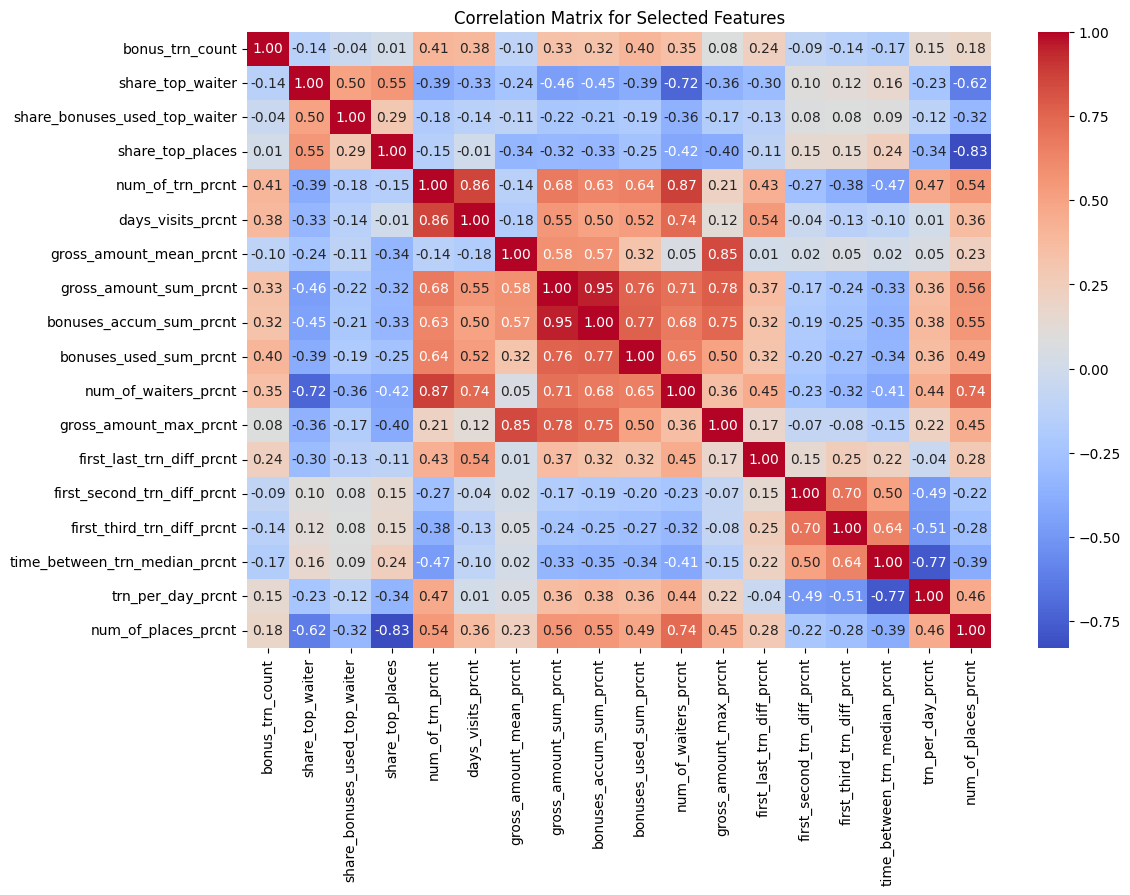

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix for selected features
corr = client_data[features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix for Selected Features")
plt.show()

In [75]:
from sklearn.manifold import TSNE
import plotly.express as px
import numpy as np

top_n = 20
detected_fraud_idx = df_iso[df_iso['anomaly_label_std'] == -1].index
real_fraud_idx = df_iso[df_iso['is_fraud'] == True].index
normal_data = df_iso[~df_iso.index.isin(detected_fraud_idx) & ~df_iso.index.isin(real_fraud_idx)]

sample_size = 10000
nonfraud_idx = normal_data.sample(n=sample_size, random_state=42).index
sample_idx = nonfraud_idx.union(real_fraud_idx)
sample_idx = sample_idx.union(detected_fraud_idx)
X_std_sample = X_std.loc[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=20)
tsne_results = tsne.fit_transform(X_std_sample)

tsne_df = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'], index=X_std_sample.index)
tsne_df['is_fraud'] = client_data.loc[X_std_sample.index, 'is_fraud']
tsne_df['anomaly_score'] = df_iso.loc[X_std_sample.index, 'anomaly_score_std']

tsne_df['group'] = 'Normal'
tsne_df.loc[tsne_df['is_fraud'] == True, 'group'] = 'Real Fraud'
tsne_df.loc[(tsne_df.index.isin(detected_fraud_idx)) & (tsne_df['is_fraud'] == False), 'group'] = 'Detected Fraud'

tsne_df['group'] = pd.Categorical(
    tsne_df['group'],
    categories=['Real Fraud', 'Detected Fraud', 'Normal'],
    ordered=True
)

color_map = {
    'Real Fraud': '#d62728',
    'Detected Fraud': '#ff7f0e',
    'Normal': '#1f77b4'
}

fig = px.scatter(
    tsne_df,
    x='tsne_1',
    y='tsne_2',
    color='group',
    color_discrete_map=color_map,
    symbol='group',
    title="t-SNE Projection: Real Fraud (red), Detected Fraud (orange), Normal Data (blue)",
    labels={'group': 'Group'},
    hover_data=['anomaly_score', 'is_fraud'],
)

fig.update_traces(marker=dict(size=5, opacity=1))
fig.show()

In [ ]:
# + 1 fraud 11738983

In [53]:
df[df['person_id'] == 16376555]['waiter_id'].value_counts()

waiter_id
54de0d442cdc51c13b68ed82_2045    37
Name: count, dtype: Int64

In [38]:
check_top_anomaly(df_iso, X_std, top_20, features)

,anomaly_score_std,bonus_trn_count,share_top_waiter,share_bonuses_used_top_waiter,share_top_places,num_of_trn_prcnt,days_visits_prcnt,gross_amount_mean_prcnt,gross_amount_sum_prcnt,bonuses_accum_sum_prcnt,bonuses_used_sum_prcnt,num_of_waiters_prcnt,gross_amount_max_prcnt,first_last_trn_diff_prcnt,first_second_trn_diff_prcnt,first_third_trn_diff_prcnt,time_between_trn_median_prcnt,trn_per_day_prcnt,num_of_places_prcnt
person_id,,,,,,,,,,,,,,,,,,,
16052012,-0.0522,99.84,99.26,91.86,85.39,99.90,93.45,54.30,99.97,99.97,99.96,0.00,97.95,13.37,13.39,5.98,2.81,100.00,0.00
16118378,-0.0392,98.69,99.26,91.86,85.39,98.71,92.87,10.96,92.02,93.67,94.65,0.00,25.01,12.37,20.83,6.29,4.21,98.52,0.00
16794470,-0.0373,97.07,99.26,91.86,85.39,97.44,72.87,43.45,96.46,98.42,97.76,0.00,91.78,6.51,27.82,10.54,9.49,99.91,0.00
11974519,-0.0372,99.83,99.12,91.86,85.39,99.86,99.75,9.76,99.35,99.41,99.49,0.74,30.33,77.96,14.79,4.24,26.64,80.82,0.00
11112614,-0.0350,99.39,99.26,91.86,85.39,99.37,98.62,7.56,94.96,90.95,93.16,0.00,74.71,24.83,22.32,7.03,17.35,87.39,0.00
11766135,-0.0350,94.93,99.18,91.72,85.39,98.81,95.45,65.54,99.59,98.90,98.73,0.74,92.28,92.88,70.16,74.29,9.93,96.13,0.00
14025190,-0.0345,97.07,99.20,78.55,85.39,99.67,72.87,11.14,98.30,99.70,99.34,0.74,45.37,6.36,20.24,4.75,1.69,100.00,0.00
14857764,-0.0338,67.75,98.81,91.12,85.39,31.30,0.00,99.44,93.50,94.20,95.42,0.74,98.06,20.21,3.55,0.43,0.32,82.21,0.00
11667048,-0.0335,76.34,99.12,91.57,85.39,99.33,42.07,10.16,95.78,91.83,92.95,4.51,32.38,5.62,13.85,2.83,1.01,100.00,0.00


In [55]:
check_real_frauds(df_iso, X_std, top_20, features)

,anomaly_score_std,gross_amount_mean,first_last_trn_diff,first_second_trn_diff,first_third_trn_diff,time_between_trn_median,trn_per_day,share_top_waiter,share_top_places,share_bonuses_used_top_waiter
person_id,,,,,,,,,,
16846666,-0.0492,19.60,6.38,28.74,9.59,7.18,99.96,99.26,85.39,91.86
16376555,-0.0491,38.66,9.86,20.24,5.98,4.85,99.94,99.26,85.39,91.86
16794470,-0.0464,43.45,6.51,27.82,10.54,9.49,99.91,99.26,85.39,91.86
16921722,-0.0447,50.79,5.73,19.78,26.43,4.88,99.88,99.26,85.39,91.86
11970409,-0.0066,95.11,7.19,9.70,1.16,12.34,98.34,98.81,79.71,0.00
11968000,-0.0000,92.63,18.12,2.43,0.32,11.00,99.07,98.95,81.07,0.00
11766135,0.0027,65.54,92.88,70.16,74.29,9.93,96.13,99.18,85.39,91.72
12396334,0.0250,90.51,7.18,19.17,9.99,19.72,81.85,99.15,84.70,0.00
13969910,0.0397,37.47,36.26,1.51,0.62,6.38,99.38,94.83,85.32,88.52


### OCSVM

#### 1st try

In [86]:
df, client_data = load_data(activity_state = 2)
client_data = client_data[client_data['days_visits'] > 2]

features = [
    'bonus_trn_count',
    'share_top_waiter',
    'share_bonuses_used_top_waiter',
    'share_top_places',
    'num_of_trn_prcnt',
    'days_visits_prcnt',
    'gross_amount_mean_prcnt',
    'gross_amount_sum_prcnt',
    'bonuses_accum_sum_prcnt',
    'bonuses_used_sum_prcnt',
    'num_of_waiters_prcnt',
    'gross_amount_max_prcnt',
    'first_last_trn_diff_prcnt',
    'first_second_trn_diff_prcnt',
    'first_third_trn_diff_prcnt',
    'time_between_trn_median_prcnt',
    'trn_per_day_prcnt',
    'num_of_places_prcnt'
]
skewed = [
    'bonus_trn_count'
]
table, df_ocsvm, top_20, X_std = test_model(client_data, features, skewed, model='ocsvm')
table

Starting test_model
One Class SVM: Anomaly Hit Rate = 0.5714, recall@20 = 0.0714, precision@20 = 0.1000


,score,is_fraud
person_id,,
11808086,-86.816420,False
6598101,-76.760303,False
12508879,-74.218252,False
16052012,-71.548590,False
12397778,-64.760196,False
11833164,-62.345809,False
11858681,-58.332740,False
11968000,-57.081992,True
11763106,-51.453200,False


In [67]:
check_top_anomaly(df_ocsvm, X_std, top_20, features)

,anomaly_score_std,bonus_trn_count,share_bonus_after_first,share_bonus_trn,share_top_waiter,share_bonuses_used_top_waiter,share_top_places,num_of_trn_prcnt,days_visits_prcnt,gross_amount_mean_prcnt,...,bonuses_accum_sum_prcnt,bonuses_used_sum_prcnt,num_of_waiters_prcnt,gross_amount_max_prcnt,first_last_trn_diff_prcnt,first_second_trn_diff_prcnt,first_third_trn_diff_prcnt,time_between_trn_median_prcnt,trn_per_day_prcnt,num_of_places_prcnt
person_id,,,,,,,,,,,,,,,,,,,,,
12508879,-76.3948,100.00,97.44,99.82,20.32,58.82,85.34,100.00,99.95,5.82,...,99.99,99.99,92.98,36.45,66.92,11.37,17.91,4.10,99.63,14.61
6598101,-76.1535,100.00,97.42,99.82,30.93,61.08,85.39,99.97,98.98,53.93,...,100.00,100.00,97.19,99.85,18.86,54.34,33.65,0.23,99.97,0.00
11808086,-73.9534,100.00,85.09,89.54,98.77,91.70,83.37,100.00,99.99,2.15,...,99.98,99.99,89.48,54.43,90.66,44.08,28.41,12.44,97.80,74.79
11690616,-63.2456,99.75,97.44,99.83,9.84,41.83,45.54,97.52,96.85,80.13,...,6.81,100.00,98.61,76.56,17.68,14.16,16.57,25.37,69.90,97.68
16052012,-61.2177,99.84,43.27,50.01,99.26,91.86,85.39,99.90,93.45,54.30,...,99.97,99.96,0.00,97.95,13.37,13.39,5.98,2.81,100.00,0.00
11750504,-56.6046,99.99,97.44,99.83,97.36,91.04,85.39,99.90,99.96,39.63,...,99.94,99.95,73.24,50.04,94.29,57.47,50.36,30.26,0.00,0.00
12397778,-54.9292,0.00,0.00,0.00,99.17,41.94,83.63,68.35,25.68,94.18,...,95.27,0.00,0.74,99.48,51.97,97.66,93.52,0.10,96.27,14.61
11833164,-53.2442,0.00,0.00,0.00,7.69,41.94,85.39,91.88,53.53,99.99,...,100.00,0.00,89.48,99.96,86.68,4.07,85.30,0.07,99.63,0.00
11858681,-51.3733,0.00,0.00,0.00,99.26,41.94,85.39,21.16,0.00,96.96,...,82.75,0.00,0.00,94.42,76.78,4.36,0.43,64.96,70.82,0.00


In [62]:
check_real_frauds(df_ocsvm, X_std, top_20, features)

,anomaly_score_std,bonus_trn_count,share_bonus_after_first,share_bonus_trn,share_top_waiter,share_bonuses_used_top_waiter,share_top_places,num_of_trn_prcnt,days_visits_prcnt,gross_amount_mean_prcnt,...,bonuses_accum_sum_prcnt,bonuses_used_sum_prcnt,num_of_waiters_prcnt,gross_amount_max_prcnt,first_last_trn_diff_prcnt,first_second_trn_diff_prcnt,first_third_trn_diff_prcnt,time_between_trn_median_prcnt,trn_per_day_prcnt,num_of_places_prcnt
person_id,,,,,,,,,,,,,,,,,,,,,
11968000,-42.2721,89.14,18.56,19.16,98.95,0.00,81.07,98.71,91.53,92.63,...,99.98,99.83,73.24,93.42,18.12,2.43,0.32,11.00,99.07,74.79
11766135,-31.3580,94.93,23.82,25.85,99.18,91.72,85.39,98.81,95.45,65.54,...,98.90,98.73,0.74,92.28,92.88,70.16,74.29,9.93,96.13,0.00
12396334,-29.0435,14.86,15.43,15.32,99.15,0.00,84.70,86.58,79.71,90.51,...,99.37,96.22,4.51,91.20,7.18,19.17,9.99,19.72,81.85,14.61
11970409,-27.5856,67.75,26.72,26.19,98.81,0.00,79.71,89.30,61.84,95.11,...,99.58,99.68,32.61,95.88,7.19,9.70,1.16,12.34,98.34,49.45
16846666,-24.7486,67.75,17.06,17.34,99.26,91.86,85.39,96.90,61.84,19.60,...,95.98,91.41,0.00,31.40,6.38,28.74,9.59,7.18,99.96,0.00
16794470,-23.3985,97.07,48.00,54.63,99.26,91.86,85.39,97.44,72.87,43.45,...,98.42,97.76,0.00,91.78,6.51,27.82,10.54,9.49,99.91,0.00
16376555,-19.9329,86.27,28.31,31.24,99.26,91.86,85.39,95.15,53.53,38.66,...,91.04,95.93,0.00,77.09,9.86,20.24,5.98,4.85,99.94,0.00
12861171,-14.7904,98.98,68.76,77.66,98.80,91.71,85.39,98.17,99.04,98.98,...,99.98,99.98,4.51,97.74,36.83,44.76,27.03,38.29,25.08,0.00
16921722,-13.7381,91.25,35.51,48.15,99.26,91.86,85.39,94.33,53.53,50.79,...,94.38,96.32,0.00,59.12,5.73,19.78,26.43,4.88,99.88,0.00


#### 2nd try

In [87]:
df, client_data = load_data(activity_state = 2)
client_data = client_data[client_data['days_visits'] > 2]

features = [
    'bonus_trn_count',
    'share_top_waiter',
    'share_bonuses_used_top_waiter',
    'share_top_places',
    'num_of_trn_prcnt',
    'days_visits_prcnt',
    'gross_amount_mean_prcnt',
    'gross_amount_sum_prcnt',
    'bonuses_accum_sum_prcnt',
    'bonuses_used_sum_prcnt',
    'num_of_waiters_prcnt',
    'gross_amount_max_prcnt',
    'first_last_trn_diff_prcnt',
    'first_second_trn_diff_prcnt',
    'first_third_trn_diff_prcnt',
    'time_between_trn_median_prcnt',
    'trn_per_day_prcnt',
    'num_of_places_prcnt'
]
skewed = [
    'bonus_trn_count'
]
table, df_ocsvm, top_20, X_std = test_model(client_data, features, skewed, model='ocsvm')
table

Starting test_model
One Class SVM: Anomaly Hit Rate = 0.5714, recall@20 = 0.0714, precision@20 = 0.1000


,score,is_fraud
person_id,,
11808086,-86.816420,False
6598101,-76.760303,False
12508879,-74.218252,False
16052012,-71.548590,False
12397778,-64.760196,False
11833164,-62.345809,False
11858681,-58.332740,False
11968000,-57.081992,True
11763106,-51.453200,False
